In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('TSLA','FN'), 
         ('TSLA','KTOS'), 
         ('TSLA','MDGL'), 
         ('AMD','FN'), 
         ('AMD', 'KTOS'),
         ('AMD', 'MDGL'), 
         ('TER','FN'), 
         ('TER', 'KTOS'), 
         ('TER','MDGL')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, 

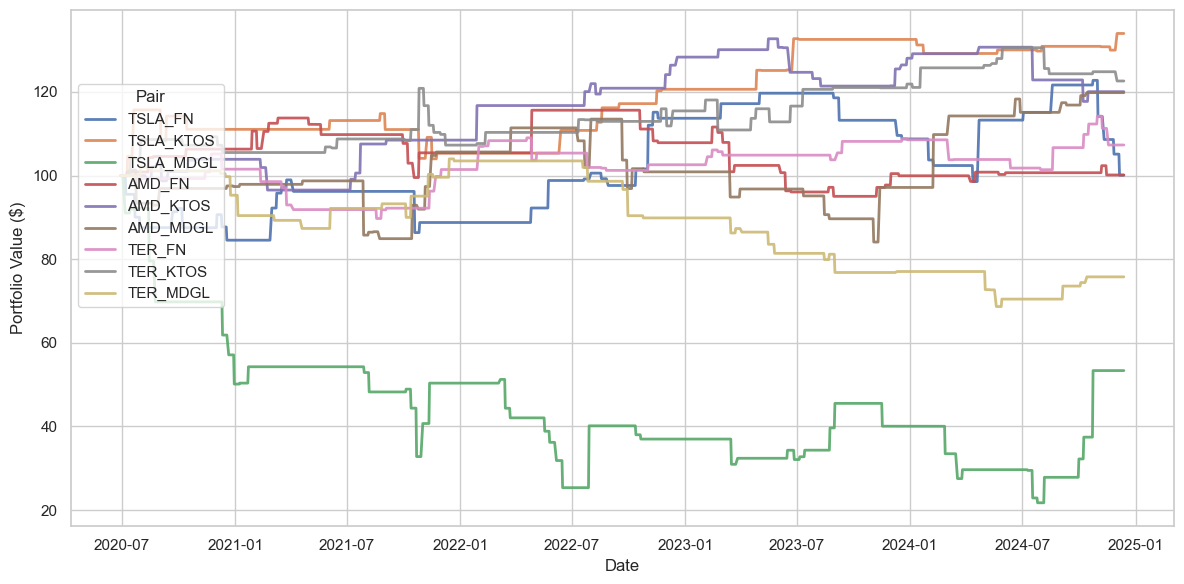

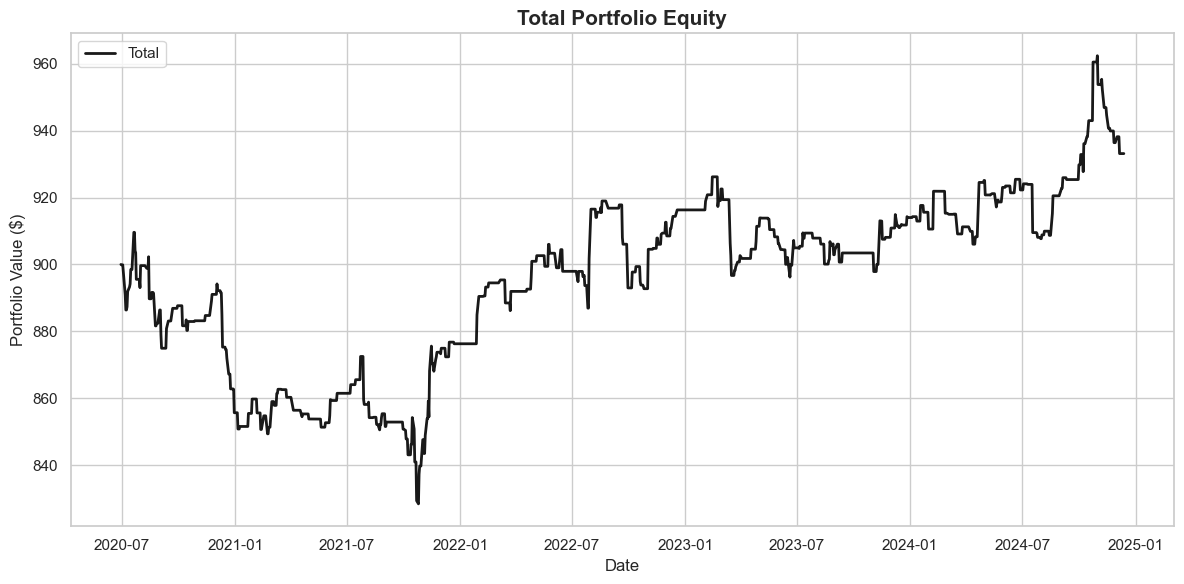

Summary
TSLA_FN: Final Value = $100.09, Total Return = 0.09%, Trades = 44
TSLA_KTOS: Final Value = $133.98, Total Return = 33.98%, Trades = 32
TSLA_MDGL: Final Value = $53.36, Total Return = -46.64%, Trades = 47
AMD_FN: Final Value = $100.14, Total Return = 0.14%, Trades = 41
AMD_KTOS: Final Value = $120.06, Total Return = 20.06%, Trades = 37
AMD_MDGL: Final Value = $119.83, Total Return = 19.83%, Trades = 40
TER_FN: Final Value = $107.31, Total Return = 7.31%, Trades = 45
TER_KTOS: Final Value = $122.62, Total Return = 22.62%, Trades = 46
TER_MDGL: Final Value = $75.77, Total Return = -24.23%, Trades = 38

Total Portfolio Performance
Initial Portfolio Value: $900.00
Final Portfolio Value:   $933.17
Total Return:            3.69%

Sharpe Ratios
TSLA_FN: Sharpe Ratio = 0.08
TSLA_KTOS: Sharpe Ratio = 0.72
TSLA_MDGL: Sharpe Ratio = -0.03
AMD_FN: Sharpe Ratio = 0.05
AMD_KTOS: Sharpe Ratio = 0.53
AMD_MDGL: Sharpe Ratio = 0.32
TER_FN: Sharpe Ratio = 0.24
TER_KTOS: Sharpe Ratio = 0.57
TER_MDG

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)